# Difusão Latente com CLIP

Neste notebook, faremos uma geração de rostos condicionada por atributos do CelebA, como sorriso, óculos, cor do cabelo e gênero. A abordagem segue o princípio do condicionamento textual em modelos de difusão latente, mas utiliza descrições derivadas de rótulos estruturados em vez de legendas livres.

A receita reaproveita duas peças pré-treinadas e congeladas. O VAE `AutoencoderKL` comprime as imagens em latentes. O codificador de texto do CLIP transforma uma descrição em uma sequência de vetores. A ponte entre os dois é simples: para cada rosto, montamos uma frase a partir dos atributos ativos, algo como `a photo of a young smiling woman with blond hair`, e deixamos o CLIP convertê-la em embedding. Assim os rótulos viram a condição da difusão. A rede de desruído é uma `UNet2DConditionModel`, que injeta esse embedding por camadas de cross-attention e é treinada do zero.

Para controlar o quanto a imagem obedece aos atributos pedidos, usaremos Classifier-Free Guidance, com a condição sendo o embedding de texto e a condição nula vindo de uma frase vazia.

## Instalação

Além da `diffusers`, usaremos a `transformers` para o CLIP e a `datasets` para o CelebA.

In [ ]:
# !pip install -q -U diffusers transformers accelerate datasets

In [1]:
import math
import textwrap
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from itertools import islice
from tqdm.auto import tqdm

from datasets import load_dataset
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo ativo: {device}")

Dispositivo ativo: cuda


## Dados

Usaremos o CelebA com seus 40 atributos faciais anotados, na versão `huggan/CelebA-faces-with-attributes`, em que cada linha traz a imagem alinhada e os atributos como rótulos binários. Cada atributo vale $1$ quando presente e $-1$ quando ausente.

Em vez de legendas livres, transformamos esses rótulos em uma frase descritiva. A função `build_prompt` junta os atributos ativos de um rosto em um texto natural, montando adjetivos antes do substantivo e complementos depois. Esse texto é a condição que o CLIP vai codificar. As imagens são redimensionadas para $128 \times 128$ e normalizadas para $[-1, 1]$; carregamos em streaming e ficamos com `num_images` exemplos.

In [ ]:
# Hiperparâmetros de dados
image_size = 128       # resolução das imagens
num_images = 16000     # tamanho do subconjunto de treino
encode_batch_size = 32 # batch usado na pré-computação

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # [0,1] -> [-1,1]
])

def to_tensor(pil_image):
    return transform(pil_image.convert("RGB"))

stream_dataset = load_dataset("huggan/CelebA-faces-with-attributes", split="train", streaming=True)
print("CelebA com atributos carregado em modo streaming.")

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

CelebA com atributos carregado em modo streaming.


In [23]:
# Constrói uma frase descritiva a partir dos atributos ativos de um rosto
def build_prompt(ex):
    def on(attr):
        return ex[attr] == 1

    adjectives = []
    if on("Young"):
        adjectives.append("young")
    if on("Smiling"):
        adjectives.append("smiling")
    if on("Chubby"):
        adjectives.append("chubby")
    noun = "man" if on("Male") else "woman"

    clauses = []
    if on("Bald"):
        clauses.append("who is bald")
    elif on("Black_Hair"):
        clauses.append("with black hair")
    elif on("Blond_Hair"):
        clauses.append("with blond hair")
    elif on("Brown_Hair"):
        clauses.append("with brown hair")
    elif on("Gray_Hair"):
        clauses.append("with gray hair")
    if on("Bangs"):
        clauses.append("with bangs")
    if not on("No_Beard"):
        clauses.append("with a beard")
    if on("Eyeglasses"):
        clauses.append("wearing eyeglasses")
    if on("Wearing_Hat"):
        clauses.append("wearing a hat")
    if on("Heavy_Makeup"):
        clauses.append("with heavy makeup")

    prompt = "a photo of a " + " ".join(adjectives + [noun])
    if clauses:
        prompt += " " + ", ".join(clauses)
    return prompt

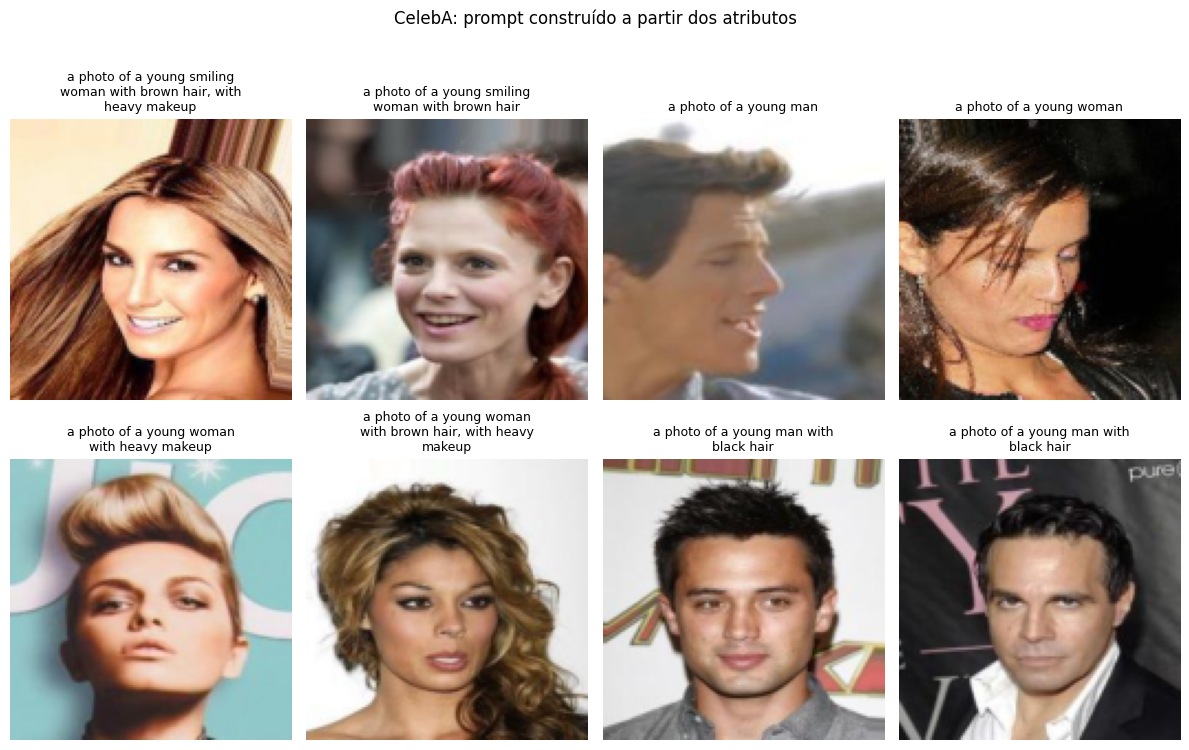

In [24]:
# Exibe imagens em [-1, 1] com seus textos
def show_captioned(imgs, captions, ncol=4, title=None):
    imgs = (imgs.clamp(-1, 1) + 1) / 2.0
    n = imgs.size(0)
    nrow = math.ceil(n / ncol)
    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 3.0, nrow * 3.8))
    axs = np.array(axs).reshape(-1)
    for i in range(len(axs)):
        axs[i].axis("off")
        if i < n:
            axs[i].imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
            axs[i].set_title(textwrap.fill(captions[i], 28), fontsize=9)
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualizar exemplos com o prompt derivado dos atributos
samples = list(islice(stream_dataset, 8))
sample_imgs = torch.stack([to_tensor(s["image"]) for s in samples])
sample_prompts = [build_prompt(s) for s in samples]
show_captioned(sample_imgs, sample_prompts, ncol=4, title="CelebA: prompt construído a partir dos atributos")

## VAE Pré-treinado

Reutilizamos o autoencoder do Stable Diffusion, `stabilityai/sd-vae-ft-mse`, que comprime cada imagem RGB de $128 \times 128$ em um latente de $4 \times 16 \times 16$. Ele entra congelado e serve apenas como codec, como no notebook anterior, então passamos direto ao texto.

In [25]:
# Carregar o VAE pré-treinado e congelá-lo
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
for param in vae.parameters():
    param.requires_grad_(False)

scaling_factor = vae.config.scaling_factor
latent_channels = vae.config.latent_channels
latent_size = image_size // 8

print(f"Formato do latente: {latent_channels} x {latent_size} x {latent_size}")

/home/silvan/anaconda3/envs/ai/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Formato do latente: 4 x 16 x 16


## Codificador de Texto

O CLIP foi treinado para alinhar imagens e textos em um mesmo espaço, o que torna suas representações de linguagem ricas em conteúdo visual. Usamos apenas o ramo de texto, o `CLIPTextModel`, o mesmo codificador do Stable Diffusion v1. A frase montada a partir dos atributos é quebrada em tokens pelo `CLIPTokenizer` e transformada em uma sequência `last_hidden_state` de formato $L \times 768$, onde $L$ é o comprimento fixo da sequência e $768$ a dimensão de cada vetor. Manter a sequência inteira permite que a U-Net atenda a cada palavra separadamente.

O codificador fica congelado. Definimos um comprimento máximo curto, suficiente para nossas descrições, e guardamos o embedding da string vazia, que representa a condição nula do Classifier-Free Guidance.

In [26]:
# Carregar o tokenizer e o codificador de texto do CLIP, congelado
clip_id = "openai/clip-vit-large-patch14"
max_length = 32

tokenizer = CLIPTokenizer.from_pretrained(clip_id)
text_encoder = CLIPTextModel.from_pretrained(clip_id, use_safetensors=True).to(device)
text_encoder.eval()
for param in text_encoder.parameters():
    param.requires_grad_(False)

text_dim = text_encoder.config.hidden_size

@torch.no_grad()
def encode_text(prompts):
    tokens = tokenizer(
        prompts, padding="max_length", max_length=max_length,
        truncation=True, return_tensors="pt",
    ).to(device)
    return text_encoder(**tokens).last_hidden_state

# Embedding da condição nula, usado no CFG
uncond_embedding = encode_text([""])

example = encode_text(["a photo of a young smiling woman with blond hair"])
print(f"Dimensão dos embeddings de texto: {text_dim}")
print(f"Formato de um embedding: {tuple(example.shape)}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}

Dimensão dos embeddings de texto: 768
Formato de um embedding: (1, 32, 768)


## Pré-computação

Como o VAE e o CLIP estão congelados, codificamos cada imagem em seu latente e cada prompt em seu embedding uma única vez, guardando os dois. O treinamento roda então direto sobre esses tensores. Amostramos o latente do posterior do VAE e já aplicamos o fator de escala.

In [27]:
# Codificar imagens em latentes e prompts de atributos em embeddings
latents_list = []
text_list = []
img_buffer = []
prompt_buffer = []

def flush():
    batch = torch.stack(img_buffer).to(device)
    with torch.no_grad():
        z = vae.encode(batch).latent_dist.sample() * scaling_factor
        c = encode_text(prompt_buffer)
    latents_list.append(z.cpu())
    text_list.append(c.cpu())

progress = tqdm(islice(stream_dataset, num_images), total=num_images, desc="Codificando CelebA")
for ex in progress:
    img_buffer.append(to_tensor(ex["image"]))
    prompt_buffer.append(build_prompt(ex))
    if len(img_buffer) == encode_batch_size:
        flush()
        img_buffer, prompt_buffer = [], []

if img_buffer:
    flush()

latents = torch.cat(latents_list, dim=0)
text_embeds = torch.cat(text_list, dim=0)
print(f"Latentes: {tuple(latents.shape)}")
print(f"Embeddings de texto: {tuple(text_embeds.shape)}")

batch_size = 128
dataset = TensorDataset(latents, text_embeds)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

Codificando CelebA:   0%|          | 0/20000 [00:00<?, ?it/s]

Failed to read file 'hf://datasets/huggan/CelebA-faces-with-attributes@b47e27a7c6bc578361ce132da8c8dad573b98d9e/data/train-00011-of-00132.parquet' with error ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.


ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

## Difusão no Espaço Latente

O processo de difusão é idêntico ao do notebook anterior, então apenas instanciamos o `DDPMScheduler` com $T = 1000$ passos e schedule linear. Toda a novidade está em como a rede recebe a condição.

In [28]:
num_train_timesteps = 1000
scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps, beta_schedule="linear")
print(f"Passos de difusão (T): {scheduler.config.num_train_timesteps}")

Passos de difusão (T): 1000


## U-Net com Cross-Attention

A `UNet2DConditionModel` estende a U-Net incondicional com camadas de cross-attention. Em cada bloco de atenção, os mapas de ativação da imagem funcionam como consultas e a sequência de embeddings de texto fornece chaves e valores, de modo que cada região do latente busca a palavra mais relevante da descrição. Indicamos isso pelos blocos `CrossAttnDownBlock2D` e `CrossAttnUpBlock2D`, e informamos a dimensão dos embeddings em `cross_attention_dim`, igual a 768 para o CLIP escolhido.

A rede recebe o latente ruidoso $z_t$, o passo $t$ e a sequência de texto via `encoder_hidden_states`, e prevê o ruído $\epsilon$ no formato $B \times 4 \times 16 \times 16$.

In [29]:
unet = UNet2DConditionModel(
    sample_size=latent_size,
    in_channels=latent_channels,
    out_channels=latent_channels,
    layers_per_block=2,
    block_out_channels=(128, 256, 512),
    down_block_types=("DownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D"),
    up_block_types=("CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "UpBlock2D"),
    cross_attention_dim=text_dim,
).to(device)

n_params = sum(p.numel() for p in unet.parameters())
print(f"Parâmetros da U-Net condicional: {n_params/1e6:.1f}M")

Parâmetros da U-Net condicional: 101.3M


## Treinamento

O objetivo é o mesmo do DDPM, a U-Net prevê o ruído adicionado ao latente, minimizando $\lVert \epsilon - \epsilon_\theta(z_t, t, c) \rVert^2$, onde $c$ é o embedding dos atributos. A diferença essencial está no preparo do Classifier-Free Guidance. A cada passo, com probabilidade de 10%, trocamos o embedding pela condição nula. Isso ensina a mesma rede a desruidar tanto condicionada aos atributos quanto sem condição, requisito para guiar a amostragem depois.

In [30]:
num_epochs = 60
uncond_dropout = 0.1
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
losses = []

print("Iniciando treinamento guiado por atributos...")
for epoch in range(num_epochs):
    unet.train()
    epoch_loss = 0.0
    progress = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs}", leave=False)
    for z0, c in progress:
        z0 = z0.to(device)
        c = c.to(device)

        # Label dropout: troca a condição pela nula em parte do batch
        drop = torch.rand(c.size(0), device=device) < uncond_dropout
        c[drop] = uncond_embedding[0]

        # Adicionar ruído e prever, condicionando nos atributos
        noise = torch.randn_like(z0)
        t = torch.randint(0, num_train_timesteps, (z0.size(0),), device=device).long()
        zt = scheduler.add_noise(z0, noise, t)
        noise_pred = unet(zt, t, encoder_hidden_states=c).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"[{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Iniciando treinamento guiado por atributos...


Época 1/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 2/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 3/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 4/60:   0%|          | 0/93 [00:00<?, ?it/s]

...

Época 57/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 58/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 59/60:   0%|          | 0/93 [00:00<?, ?it/s]

Época 60/60:   0%|          | 0/93 [00:00<?, ?it/s]

[60/60] Loss: 0.1534


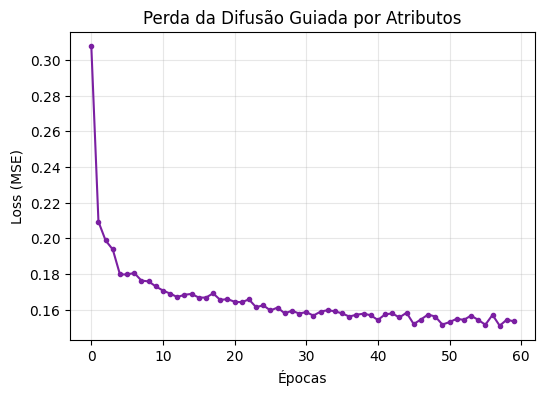

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(losses, color="#7b1fa2", marker="o", markersize=3)
plt.title("Perda da Difusão Guiada por Atributos")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True, alpha=0.3)
plt.show()

## Amostragem com CFG

Na geração computamos em cada passo duas previsões de ruído, uma condicionada à descrição $c$ e outra à condição nula $\varnothing$, e as combinamos:

$$\tilde{\epsilon}_\theta(z_t, t, c) = \epsilon_\theta(z_t, t, \varnothing) + s \,\big[\epsilon_\theta(z_t, t, c) - \epsilon_\theta(z_t, t, \varnothing)\big]$$

A escala $s$ controla a adesão aos atributos: $s = 0$ ignora a descrição, $s = 1$ recupera a geração condicional usual e $s > 1$ amplifica os traços pedidos. Para eficiência, empilhamos as entradas condicional e incondicional em um único batch e fazemos uma passagem só pela U-Net por passo. Ao final, o decoder devolve as imagens.

In [32]:
@torch.no_grad()
def generate(prompts, guidance_scale=7.5, num_inference_steps=1000, seed=None):
    "Gera rostos a partir de descrições de atributos usando CFG."
    if seed is not None:
        torch.manual_seed(seed)
    unet.eval()

    n = len(prompts)
    cond = encode_text(prompts)
    uncond = uncond_embedding.repeat(n, 1, 1)
    emb = torch.cat([uncond, cond], dim=0)   # incondicional empilhado com condicional

    scheduler.set_timesteps(num_inference_steps)
    z = torch.randn(n, latent_channels, latent_size, latent_size, device=device)

    for t in tqdm(scheduler.timesteps, desc="Amostrando", leave=False):
        latent_in = torch.cat([z, z], dim=0)
        noise_pred = unet(latent_in, t, encoder_hidden_states=emb).sample
        noise_uncond, noise_cond = noise_pred.chunk(2)
        noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
        z = scheduler.step(noise_pred, t, z).prev_sample

    imgs = vae.decode(z / scaling_factor).sample
    return imgs.cpu()

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

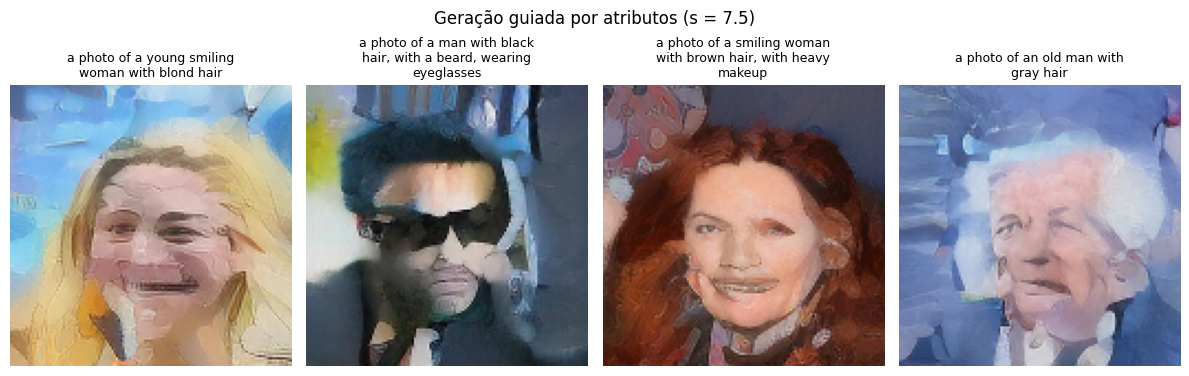

In [35]:
# Gerar rostos para diferentes combinações de atributos
prompts = [
    "a photo of a young smiling woman with blond hair",
    "a photo of a man with black hair, with a beard, wearing eyeglasses",
    "a photo of a smiling woman with brown hair, with heavy makeup",
    "a photo of an old man with gray hair",
]
imgs = generate(prompts, guidance_scale=7.5, seed=0)
show_captioned(imgs, prompts, ncol=4, title="Geração guiada por atributos (s = 7.5)")

## Efeito da Escala de Guidance

Fixando uma descrição e variando $s$, vemos o compromisso entre fidelidade aos atributos e diversidade. Valores baixos produzem rostos mais variados porém menos aderentes, enquanto valores altos reforçam os atributos pedidos, ao custo de saturação e menos variedade. Usamos a mesma semente em todas as escalas, de forma que partam do mesmo ruído inicial.

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

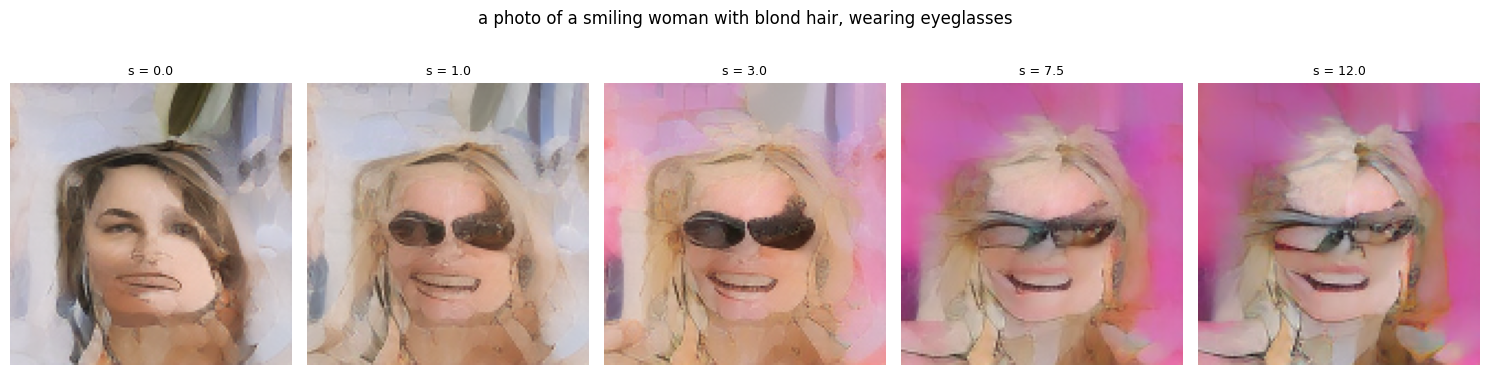

In [36]:
prompt = "a photo of a smiling woman with blond hair, wearing eyeglasses"
scales = [0.0, 1.0, 3.0, 7.5, 12.0]

scale_imgs = torch.cat([generate([prompt], guidance_scale=s, seed=1) for s in scales], dim=0)
titles = [f"s = {s}" for s in scales]
show_captioned(scale_imgs, titles, ncol=5, title=prompt)

## Exercícios

### Exercício 1
O embedding nulo do CFG vem da string vazia, mas pode ser qualquer texto. Troque a condição incondicional por um prompt negativo, por exemplo `eyeglasses, hat`, e observe como a amostragem passa a evitar esses atributos. Esse é o mecanismo de negative prompt das ferramentas atuais.

### Exercício 2
Troque o `DDPMScheduler` por um `DDIMScheduler` e gere com `num_inference_steps=50`, reaproveitando os pesos treinados. Compare qualidade, aderência aos atributos e tempo por imagem com os 1000 passos do DDPM.

### Exercício 3
Em vez de passar pelos textos do CLIP, condicione direto no vetor de atributos. Monte um vetor de 40 dimensões com os rótulos e projete-o com uma pequena rede para a dimensão de cross-attention, substituindo o embedding do CLIP. Compare a qualidade e a controlabilidade dessas duas formas de transformar rótulos em embeddings.